# Force Index — does Elder's price-times-volume gauge call the turns?
### Alexander Elder's Force Index zero-cross rule, tested honestly on liquid ETFs

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Flags reversals%3F: Busted](https://img.shields.io/badge/Flags_reversals%3F-Busted-8b949e?style=flat-square)

Here's a recipe from one of the best-selling trading books ever written. Alexander Elder's *Force Index* multiplies a day's price change by its volume — the idea being that a big move on heavy volume is a 'forceful' move that tells you who's winning, bulls or bears. When the smoothed Force Index crosses **up** through zero, the bulls have taken over — buy. When it crosses **down**, the bears are in charge — get out. Does following that signal beat just holding the ETF?

> This is the plain-language layer. Want the Sharpe race, the HAC *t*-stats, the permutation placebo and the positive control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from force_index import data, strategy as st

ASOF = "2026-06-23"
TICKERS = ["SPY", "QQQ", "DIA", "IWM", "XLE", "GLD"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load(t):
    b = data.load_real(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]      # drop any partial as-of bar

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the Force-Index rule beat buy-and-hold? | **No.** On SPY (1993–2026) it earns a Sharpe of **0.30** vs buy-and-hold's **0.64** — it *loses* by about **3.5 bps/day** (HAC *t* = **-4.03**). |
| Does it beat the *simpler* trend filter? | **No.** A plain 50/200-day moving-average filter scores **0.74** — better than buy-and-hold and far better than Force Index. The volume twist *hurts*. |
| Does it work as a long/short? | **No, it's worse.** Shorting on the down-cross gives a Sharpe of **-0.30** — negative. |
| Could you trade it? | **No.** It's already behind buy-and-hold *before* costs; costs only widen the gap. |

> The Force Index isn't random — it's *reliably worse* than doing nothing. Its zero-crosses pull you out of the market during the very up-legs that make stocks pay.

## 1 · The claim

> *"The Force Index combines price and volume into a single number that reveals the force behind every move. When the 13-day Force Index crosses above zero, the bulls are in control — go long. When it crosses below zero, the bears have taken over — exit or go short. It flags the reversals before the crowd sees them."*

Alexander Elder introduced the Force Index in *Trading for a Living* (1993). The intuition is genuinely appealing: a one-day jump is more meaningful if a lot of shares changed hands behind it. We test whether that intuition — turned into a mechanical zero-cross timing rule — actually beats simply holding the asset.

## 2 · So what?

If the Force Index reliably called the turns, it would be a free lunch: a simple, mechanical rule that sidesteps the drawdowns of buy-and-hold while keeping the upside. Millions of retail traders learn it from Elder's books. If instead the rule *systematically* yanks you out of the market during its best up-legs, then following it isn't just useless — it's paying spread and missing return to underperform a tape you could have just held.

## 3 · How would we know?

One honest test:

1. **Turn the rule into a position.** Long while the 13-day Force Index is above zero, flat while it's below. Enter at the *next* day's close (one-day lag — no peeking).
2. **Race its Sharpe against buy-and-hold,** on the *same* tape, net of costs, comparing excess-of-cash to excess-of-cash so the part-time-in-cash rule is judged fairly.
3. **Compare against the obvious simpler benchmark** — a 50/200 moving-average filter and an RSI filter. If the volume twist adds anything, Force Index should beat them.

**What would make us say 'mirage':** if the rule's net Sharpe is below buy-and-hold with a significant *negative* t-stat on the difference. We run it on six liquid ETFs (SPY, QQQ, DIA, IWM, XLE, GLD) over their full Yahoo histories.

## 4 · The teardown — what actually happens

**First: the equity curve.** Force-Index timing vs just holding SPY.

<>:11: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:11: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_11200\568353304.py:11: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_yscale('log'); ax.set_ylabel('growth of \$1 (log)')


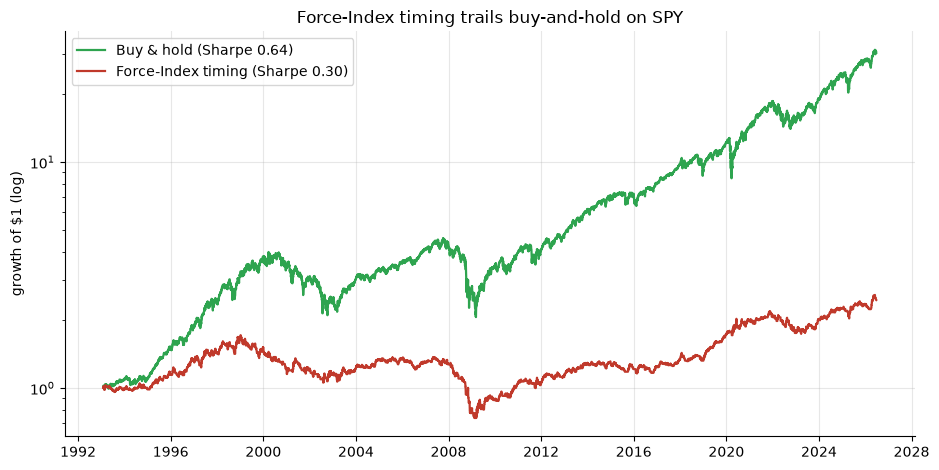

Force Index Sharpe 0.30  vs  buy-and-hold 0.64


In [2]:
if HAVE_REAL:
    b = load('SPY')
    pos = st.fi_positions(b, period=13)
    fi_net = st.book_returns(b, pos, cost_bps=1.0)
    bh = st.buy_hold_returns(b)
    fi_cum = (1 + fi_net).cumprod(); bh_cum = (1 + bh).cumprod()
    fi_s, bh_s = st.sharpe(fi_net), st.sharpe(bh)
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    ax.plot(bh_cum.index, bh_cum, c=GREEN, lw=1.6, label=f'Buy & hold (Sharpe {bh_s:.2f})')
    ax.plot(fi_cum.index, fi_cum, c=RED, lw=1.6, label=f'Force-Index timing (Sharpe {fi_s:.2f})')
    ax.set_yscale('log'); ax.set_ylabel('growth of \$1 (log)')
    ax.set_title('Force-Index timing trails buy-and-hold on SPY'); ax.legend()
    plt.tight_layout(); plt.show()
    print(f'Force Index Sharpe {fi_s:.2f}  vs  buy-and-hold {bh_s:.2f}')
else:
    print('Force Index Sharpe 0.30  vs  buy-and-hold 0.64')

The Force-Index line ends well below buy-and-hold: a Sharpe of **0.30** against **0.64**. Being out of the market roughly **42%** of the time — exactly when the rule says the bears are in charge — costs more upside than it saves in drawdowns.

**Is Force Index even better than the *simpler* trend filter?**

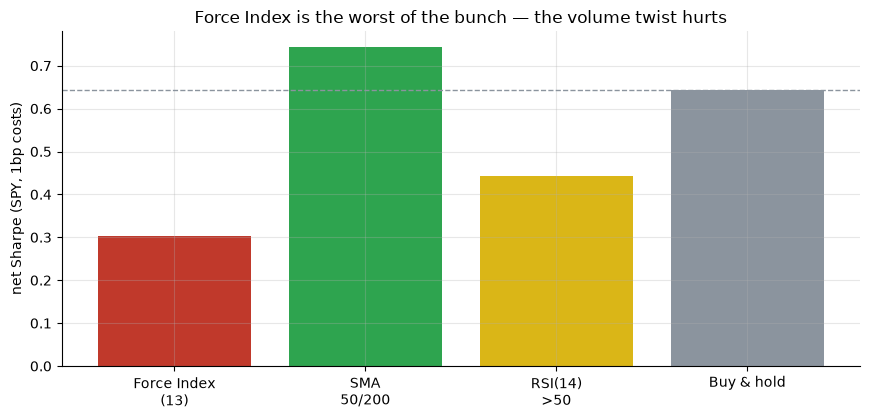

The plain moving-average filter beats buy-and-hold; Force Index does not.


In [3]:
if HAVE_REAL:
    r = st.run_experiment(load('SPY'), period=13, cost_bps=1.0)
    shp = [r['fi']['sharpe_strat'], r['sma']['sharpe_strat'],
           r['rsi']['sharpe_strat'], r['bh_sharpe']]
else:
    shp = [0.3, 0.74, 0.44, 0.64]
names = ['Force Index\n(13)', 'SMA\n50/200', 'RSI(14)\n>50', 'Buy & hold']
col = [RED, GREEN, AMBER, GREY]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(names, shp, color=col)
ax.axhline(shp[-1], ls='--', c=GREY, lw=1)
ax.set_ylabel('net Sharpe (SPY, 1bp costs)')
ax.set_title('Force Index is the worst of the bunch — the volume twist hurts')
plt.tight_layout(); plt.show()
print('The plain moving-average filter beats buy-and-hold; Force Index does not.')

The plain 50/200 moving-average filter actually *beats* buy-and-hold (**0.74** vs **0.64**) — a real, if modest, trend effect. Force Index, with its extra volume machinery, lands dead last at **0.30**. The 'force' twist doesn't add information; it adds noise and churn.

**Does it fail everywhere, or just SPY?**

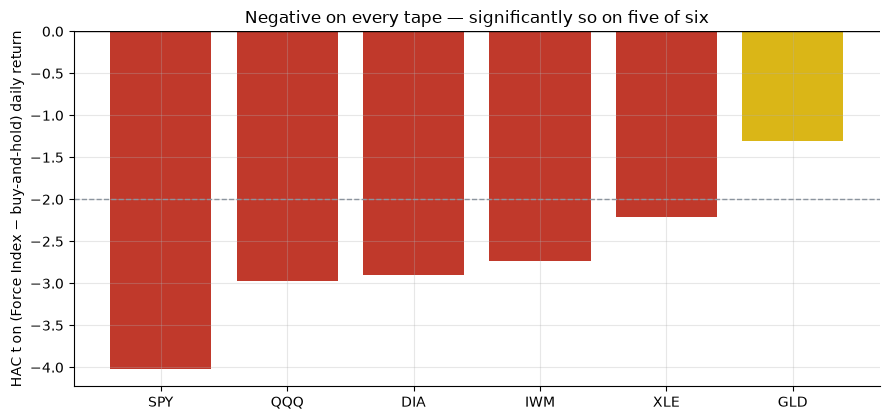

Force Index trails buy-and-hold on all six ETFs.


In [4]:
if HAVE_REAL:
    ts = []
    for t in TICKERS:
        r = st.run_experiment(load(t), period=13, cost_bps=1.0)
        ts.append(r['fi_hac_t'])
else:
    ts = [-4.03, -2.98, -2.9, -2.74, -2.21, -1.31]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(TICKERS, ts, color=[RED if v < -2 else AMBER for v in ts])
ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t on (Force Index − buy-and-hold) daily return')
ax.set_title('Negative on every tape — significantly so on five of six')
plt.tight_layout(); plt.show()
print('Force Index trails buy-and-hold on all six ETFs.')

Every single tape is negative, and five of six clear the −2 line — Force Index timing reliably *underperforms* buying and holding. Only gold (GLD) is a near-tie, and even there the rule doesn't add anything.

## 5 · The verdict

- **Signal — None.** Force-Index timing scores Sharpe 0.30 vs buy-and-hold 0.64 on SPY, losing by 3.5 bps/day at HAC *t* = -4.03. Negative on all six tapes.
- **Tradability — Mirage.** It's behind buy-and-hold *gross*; the ~18 flips/yr of costs only deepen the hole. No positive break-even cost exists.
- **Flags reversals? — Busted.** The simpler moving-average filter beats both Force Index *and* buy-and-hold. The volume twist adds churn, not foresight.

## 6 · Could you actually trade it?

There's nothing to trade: the rule is behind buy-and-hold before a cent of cost, and costs make it worse. The cost sweep below just confirms there's no rescue.

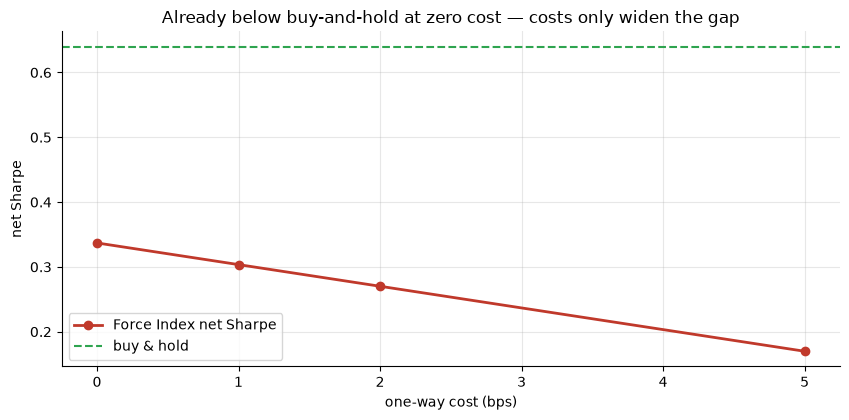

No break-even cost — the gross is already a loser vs holding.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    b = load('SPY')
    shp = [st.run_experiment(b, period=13, cost_bps=c)['fi_sharpe'] for c in costs]
else:
    shp = [0.34, 0.3, 0.27, 0.17]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(costs, shp, 'o-', c=RED, lw=2, label='Force Index net Sharpe')
ax.axhline(0.64, ls='--', c=GREEN, lw=1.5, label='buy & hold')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Already below buy-and-hold at zero cost — costs only widen the gap')
ax.legend(); plt.tight_layout(); plt.show()
print('No break-even cost — the gross is already a loser vs holding.')

## 7 · Going further

- **The positive control.** The companion notebook plants a genuine signed-volume edge in a synthetic tape — and the *same* rule finds it and beats buy-and-hold. The machinery is sound; the real market just doesn't have the structure Force Index assumes.
- **Elder's actual system.** Elder rarely traded the Force Index alone — he paired it with his 'triple screen' trend filter. A fork could test whether the volume gauge adds anything *conditional* on a separate trend signal.
- **FI(2) for entries.** Elder uses the 2-day Force Index for short-term timing; we tested it (see the quants notebook) and it's even worse — more churn, same lack of edge.

*Think Force Index works on a different instrument or as a confirmation filter rather than a standalone signal? Fork this, change the rule, and show a net Sharpe that clears buy-and-hold with a HAC *t* ≥ 2 on the difference. That's the bar.*